# Trabajo Práctico N°1:
# Modelo predictivo de tarifas de Uber


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import warnings
warnings.filterwarnings("ignore")



# Analisis descriptivo
Punto 3

In [2]:
# Comenzamos con la descarga del csv 
datos = pd.read_csv('uber_fares.csv')
datos.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:50:00,8.47,2015-05-07 19:50:00 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:00:04,7.60,2009-07-17 20:00:04 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:49:07,12.65,2009-08-24 21:49:07 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:17:45,5.01,2009-06-26 08:17:45 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:46:18,15.64,2014-08-28 17:46:18 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [3]:
datos = datos.rename(columns={'date': 'fecha',
                              'fare_amount': 'costo',
                              'pickup_datetime': 'fecha_tax',
                              'pickup_longitude': 'long_activ_tax',
                              'pickup_latitude': 'lat_activ_tax',
                              'dropoff_longitude': 'long_fin_tax',
                              'dropoff_latitude': 'latit_fin_tax', 
                              'passenger_count': 'cant_pasajeros'})

datos.head()

,key,fecha,costo,fecha_tax,long_activ_tax,lat_activ_tax,long_fin_tax,latit_fin_tax,cant_pasajeros
0,24238194,2015-05-07 19:50:00,8.47,2015-05-07 19:50:00 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:00:04,7.60,2009-07-17 20:00:04 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:49:07,12.65,2009-08-24 21:49:07 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:17:45,5.01,2009-06-26 08:17:45 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:46:18,15.64,2014-08-28 17:46:18 UTC,-73.925023,40.744085,-73.973082,40.761247,5


In [4]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   key             200000 non-null  int64  
 1   fecha           200000 non-null  object 
 2   costo           200000 non-null  float64
 3   fecha_tax       200000 non-null  object 
 4   long_activ_tax  200000 non-null  float64
 5   lat_activ_tax   200000 non-null  float64
 6   long_fin_tax    199999 non-null  float64
 7   latit_fin_tax   199999 non-null  float64
 8   cant_pasajeros  200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [5]:
# Filtro para coordenadas GPS válidas
datos = datos[(datos['lat_activ_tax'] != 0) & (datos['latit_fin_tax'] != 0)]

In [6]:
# Tratamiento de datos faltantes
# Eliminamos registros con valores nulos
datos.dropna(inplace=True)

# Creacion de variables temporales y distancia
datos['fecha'] = pd.to_datetime(datos['fecha'])
datos['horario'] = datos['fecha'].dt.hour
datos['dia_semana'] = datos['fecha'].dt.dayofweek

# Distancia en km
def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Radio de la Tierra en km
    
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

datos['distancia'] = haversine(datos['lat_activ_tax'], datos['long_activ_tax'],datos['latit_fin_tax'], datos['long_fin_tax']) 

# Eliminamos columnas que ya no aportan información para el modelo
datos = datos.drop(['fecha', 'fecha_tax', 'key'], axis=1)

print(f" Registros finales: {len(datos)}")

 Registros finales: 196046


In [7]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 196046 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   costo           196046 non-null  float64
 1   long_activ_tax  196046 non-null  float64
 2   lat_activ_tax   196046 non-null  float64
 3   long_fin_tax    196046 non-null  float64
 4   latit_fin_tax   196046 non-null  float64
 5   cant_pasajeros  196046 non-null  int64  
 6   horario         196046 non-null  int32  
 7   dia_semana      196046 non-null  int32  
 8   distancia       196046 non-null  float64
dtypes: float64(6), int32(2), int64(1)
memory usage: 13.5 MB


In [8]:
# Seleccion de variables predictoras y variable objetivo
X = datos[['distancia', 'horario', 'dia_semana', 'cant_pasajeros']]
y = datos['costo']

# Validacion cruzada (Split Train/Test 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

datos_train = pd.concat([X_train, y_train], axis=1)

print(f"Conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test.shape[0]} muestras")

Conjunto de entrenamiento: 156836 muestras
Conjunto de prueba: 39210 muestras


Análisis sobre las distribuciones y valores atipicos de las variables:

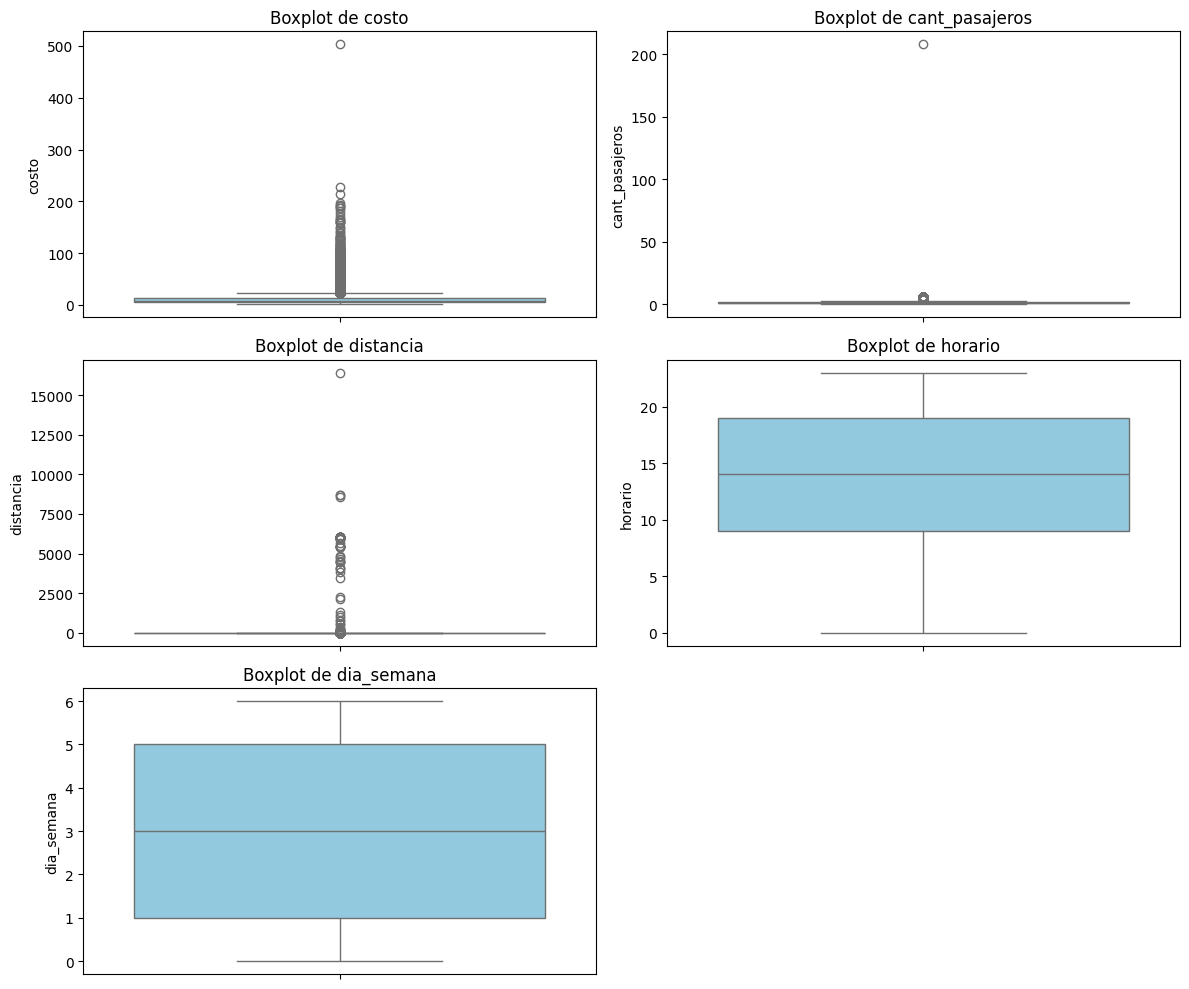

In [9]:
# BOXPLOTS
columnas_visualizacion = ['costo', 'cant_pasajeros', 'distancia', 'horario', 'dia_semana']

plt.figure(figsize=(12,10))

for i, col in enumerate(columnas_visualizacion):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(data=datos_train, y=col, color='skyblue')
    plt.title(f"Boxplot de {col}")

plt.tight_layout()
plt.show()

Se observan valores extremos en las variables costo, cant_pasajeros y distancia, por lo que establecimos criterios lógicos basados en el contexto del servicio de viajes para identificar y tratar aquellos registros que resultan inconsistentes o poco realistas.

In [10]:
# Tratamiento de outliers 
datos_train = datos_train[(datos_train['costo'] >= 0) & (datos_train['costo'] <= 100)]
datos_train = datos_train[(datos_train['cant_pasajeros'] > 0) & (datos_train['cant_pasajeros'] <= 6)]
datos_train = datos_train[(datos_train['distancia'] > 0.5) & (datos_train['distancia'] <80)]

Decidimos acotar la distancia a un máximo de 100 km y un minimo de 500 mtrs con el objetivo de eliminar valores atípicos que podrían distorsionar el análisis. Puede ser común encontrar viajes con valores extremos, ya sea por errores de carga o por situaciones poco representativas por ejemplo, viajes muy largos o tarifas inusuales.
Al aplicar estos límites, se busca trabajar con datos más representativos del comportamiento general, mejorando la estabilidad de los modelos y evitando que los outliers influyan negativamente en el entrenamiento.

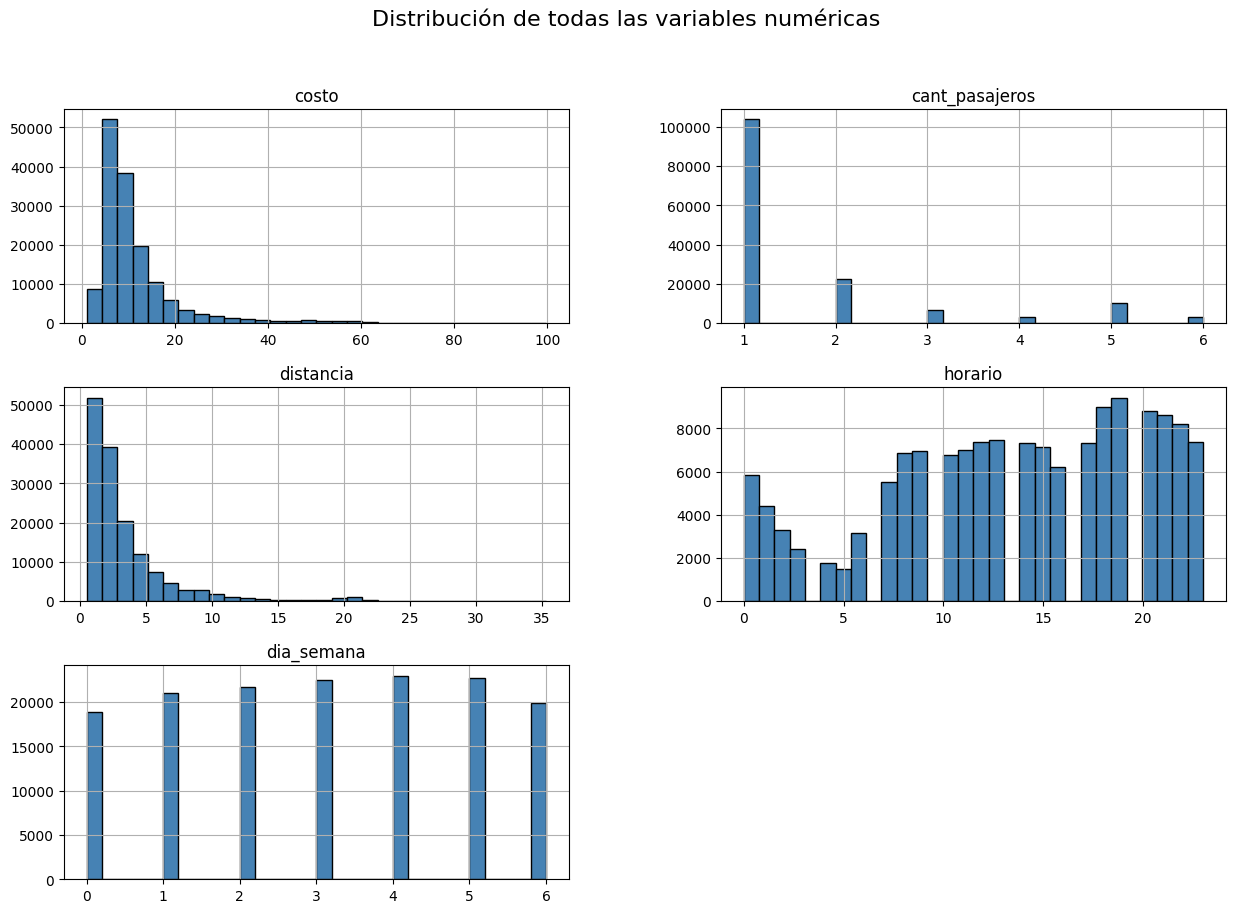

In [11]:
# HISTOGRAMAS 
datos_train[columnas_visualizacion].hist(bins=30, figsize=(15, 10), color='steelblue', edgecolor='black')
plt.suptitle('Distribución de todas las variables numéricas', fontsize=16)
plt.show()

Análisis de Distribuciones :

Costo y Distancia :
Ambas presentan un sesgo a la derecha (asimetría positiva). La mayoría de los viajes son cortos y baratos.
La moda del costo está cerca de los 10 USD, y la de la distancia alrededor de los 2-3 km.

Cant_pasajeros :
Se puede distinguir claramente que los viajes son mayormente individuales.

Horario :
La actividad empieza a subir fuerte desde las 8:00 y alcanza su pico máximo por la tarde/noche (entre las 18:00 y las 20:00), coincidiendo probablemente con la salida del trabajo y actividades sociales.

Dia_semana :
Las barras son similares, hay un ligero aumento hacia los días centrales y finales de la semana (miércoles a viernes), pero en general los dias presentan una cantidad pareja de viajes.

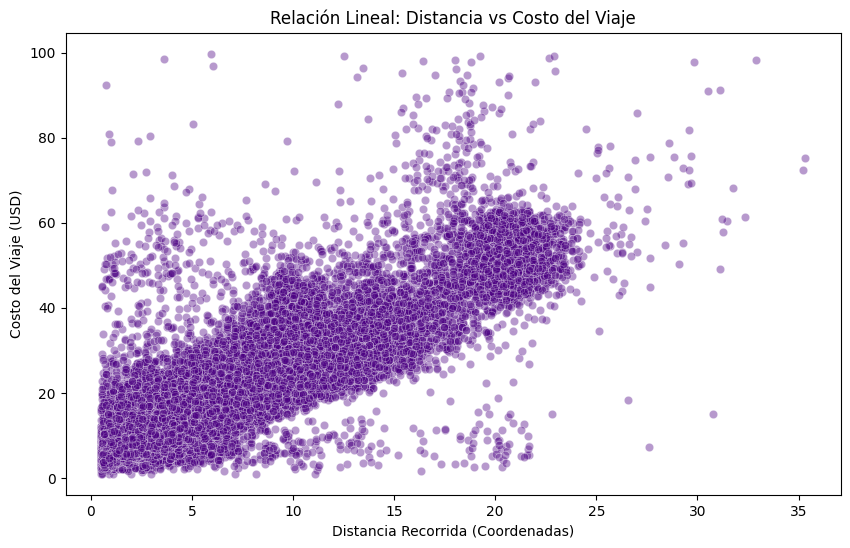

In [12]:
# SCATTERPLOT (costo vs distancia)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=datos_train, x='distancia', y='costo', alpha=0.4, color='indigo')
plt.title('Relación Lineal: Distancia vs Costo del Viaje')
plt.xlabel('Distancia Recorrida (Coordenadas)')
plt.ylabel('Costo del Viaje (USD)')
plt.show()

 Se identifica una tendencia lineal positiva entre la distancia y el costo, a mayor distancia incrementa el precio del viaje.

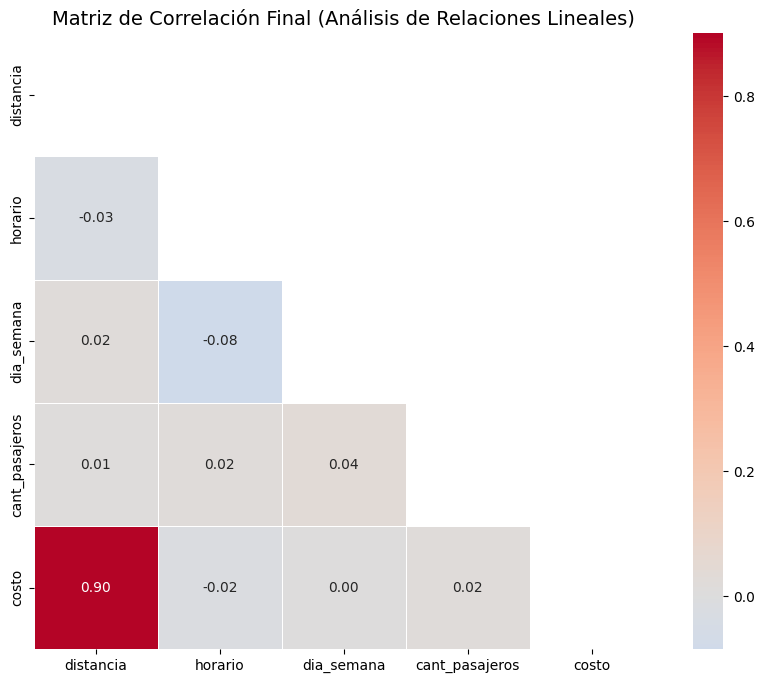

In [13]:
# MATRIZ DE CORRELACION 
plt.figure(figsize=(10, 8))

# Filtramos solo las columnas numuricas para evitar errores con fechas o textos
corr = datos_train.select_dtypes(include=[np.number]).corr()

# Mascara para ver solo la mitad y que sea mas claro
mask = np.triu(np.ones_like(corr, dtype=bool)) 

sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, center=0)
plt.title('Matriz de Correlación Final (Análisis de Relaciones Lineales)', fontsize=14)
plt.show()


El analisis de correlación de Pearson arroja un valor de 0.90 entre la distancia y el costo del viaje. Esto confirma una relación lineal muy fuerte, validando nuestra hipótesis de que la distancia es el principal predictor de la tarifa.

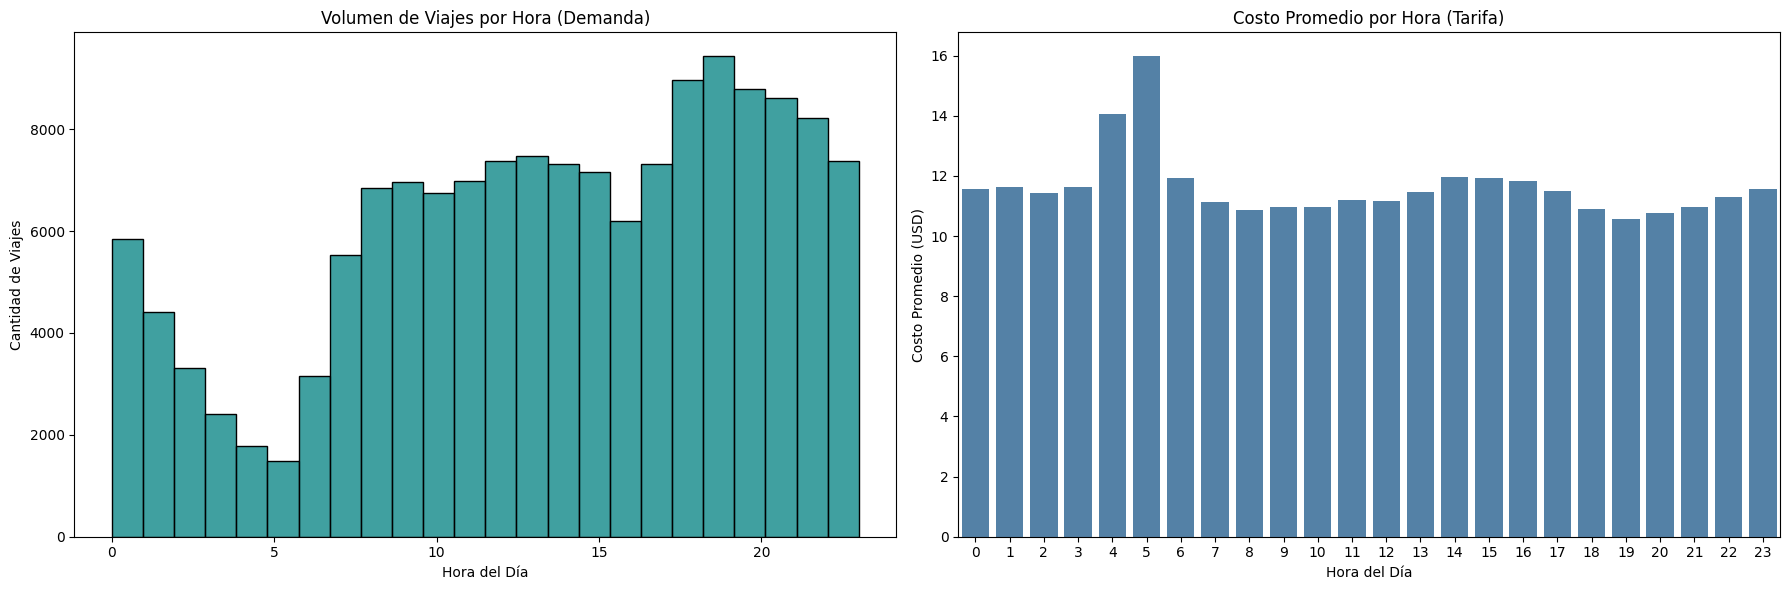

In [14]:
#  Analisis dual de la Variable Horaria 
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

#  Volumen de demanda (Histograma)
sns.histplot(x='horario', data=datos_train, bins=24, color='teal', ax=axes[0])
axes[0].set_title('Volumen de Viajes por Hora (Demanda)')
axes[0].set_xlabel('Hora del Día')
axes[0].set_ylabel('Cantidad de Viajes')

#  Precio promedio (Barplot)
prom_hora = datos.groupby('horario')['costo'].mean()
sns.barplot(x=prom_hora.index, y=prom_hora.values, color ='steelblue', ax=axes[1])
axes[1].set_title('Costo Promedio por Hora (Tarifa)')
axes[1].set_xlabel('Hora del Día')
axes[1].set_ylabel('Costo Promedio (USD)')

plt.tight_layout()
plt.show()

Presentamos este análisis dual para demostrar que la cantidad de viajes no siempre es proporcional al costo. Mientras que el volumen máximo ocurre en horario laboral, el costo promedio tiene picos en horarios nocturnos, lo que justifica por qué el modelo necesita esta variable para predecir correctamente.

In [15]:
X_train = datos_train[['distancia', 'horario', 'dia_semana']] 
y_train = datos_train['costo']

In [16]:
datos_test = pd.concat([X_test, y_test], axis=1)

# Tratamiento de outliers 
datos_test = datos_test[(datos_test['distancia'] > 0.5) & (datos_test['distancia'] < 100)]
datos_test = datos_test[(datos_test['cant_pasajeros'] > 0) & (datos_test['cant_pasajeros'] <= 6)]

X_test = datos_test[['distancia', 'horario', 'dia_semana']]
y_test = datos_test['costo']

Determinamos los datos y la limpieza de los datos de testeo, usando el mismo criterio que los de entrenamiento.

PUNTO 4 

In [17]:
X_train = X_train.values
X_test  = X_test.values

y_train = y_train.values.reshape(-1, 1)
y_test  = y_test.values.reshape(-1, 1)

In [18]:
# Estandarizacion de datos
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [19]:
# Regresion Lineal:
lr = LinearRegression()
lr.fit(X_train, y_train)
print(f"R2 Score Regresión Lineal: {lr.score(X_test, y_test):.4f}")

R2 Score Regresión Lineal: 0.7231


En este bloque preparamos los datos pasándolos a matrices de NumPy y los estandarizamos con StandardScaler para que los algoritmos funcionen mejor y converjan más rápido. Después entrenamos una Regresión Lineal clásica y calculamos el R², que nos sirve como punto de referencia (baseline) para comparar con los modelos que vamos a implementar usando Gradiente Descendiente.

In [20]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=11):
    n = X_train.shape[0]
    m = X_train.shape[1]
     
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):

        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]


        for j in range(0, n, batch_size):
            # Obtener un lote (mini-batch) de datos
            x_batch = X_train[j:j+batch_size, :]
            y_batch = y_train[j:j+batch_size].reshape(-1, 1)

            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction
            train_mse = np.mean(error ** 2)
            train_errors.append(train_mse)

            gradient = -2 * np.matmul(x_batch.T, error) / batch_size

            W = W - (lr * gradient)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (Mini-Batch GD)')
    plt.show()

    return W

In [21]:
def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):

    n = X_train.shape[0]
    m = X_train.shape[1]

    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors = []
    test_errors = []

    for i in range(epochs):
        # Permutación aleatoria de los datos
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]

        for j in range(n):
            # Obtener una muestra aleatoria de un solo dato para hacer SGD
            x_sample = X_train[j]
            y_sample = y_train[j][0]

            prediction = np.matmul(x_sample, W)
            error = y_sample - prediction
            train_mse = error ** 2
            train_errors.append(train_mse)

            prediction_test = np.matmul(X_test, W)
            error_test = y_test - prediction_test
            test_mse = np.mean(error_test ** 2)
            test_errors.append(test_mse)

            gradient = -2 * error * x_sample.T.reshape(-1, 1)

            W = W - (lr * gradient)


    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de entrenamiento')
    plt.plot(test_errors, label='Error de prueba')
    plt.xlabel('Iteración')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y prueba vs iteraciones (SGD)')
    plt.show()

    return W

In [22]:
def gradient_descent(X_train, y_train, X_val, y_val, lr=0.01, epochs=100):
    """
    shapes:
        X_train = nxm
        y_train = nx1
        X_val = pxm
        y_test = px1
        W = mx1
    """
    n = X_train.shape[0]
    m = X_train.shape[1]

    o = X_val.shape[0]

    # Poner columna de unos a las matrices X
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_val = np.hstack((np.ones((o, 1)), X_val))


    # Inicializar pesos aleatorios
    W = np.random.randn(m+1).reshape(m+1, 1)

    train_errors = []  # Para almacenar el error de entrenamiento en cada época
    test_errors = []   # Para almacenar el error de prueba en cada época

    for _ in range(epochs):
        # Calcular predicción y error de entrenamiento
        prediction_train = np.matmul(X_train, W)
        error_train = y_train - prediction_train
        #print(error_train)
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # Calcular predicción y error de prueba
        prediction_test = np.matmul(X_val, W)
        error_test = y_val - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        # Calcular el gradiente y actualizar pesos
        grad_sum = np.sum(error_train * X_train, axis=0)
        grad_mul = -2/n * grad_sum  # 1xm
        gradient = np.transpose(grad_mul).reshape(-1, 1)  # mx1

        W = W - (lr * gradient)

    # Graficar errores de entrenamiento y prueba
    plt.figure(figsize=(12, 6))
    # Plotear errores de entrenamiento
    plt.plot(train_errors, label='Error de entrenamiento')
    # Plotear errores de prueba
    plt.plot(test_errors, label='Error de validación')
    # Poner labels en los ejes
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title('Error de entrenamiento y validación vs iteraciones (GD)')
    plt.show()

    return W

En esta etapa del proyecto, el objetivo central fue encontrar los pesos óptimos ($W$) que relacionan las variables del viaje (distancia, horario, día y pasajeros) con el costo final de la tarifa. Para asegurar la robustez del modelo, implementamos y comparamos tres variantes del algoritmo de Gradiente Descendiente y validamos los resultados mediante modelos de regularización.

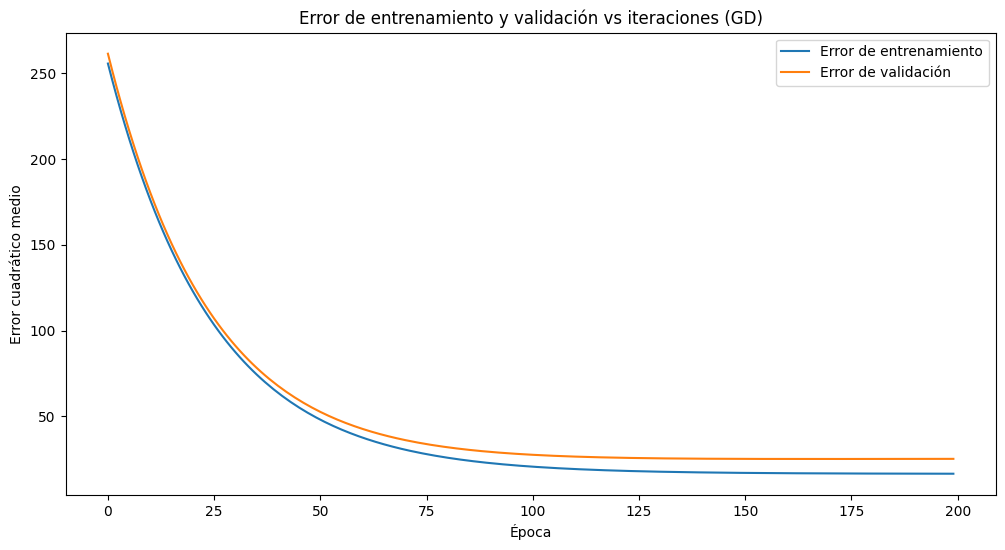

array([[11.22216892],
       [ 8.26024895],
       [ 0.08024375],
       [-0.09894828]])

In [23]:
gradient_descent( X_train, y_train,X_test, y_test,lr=0.01,epochs=200)

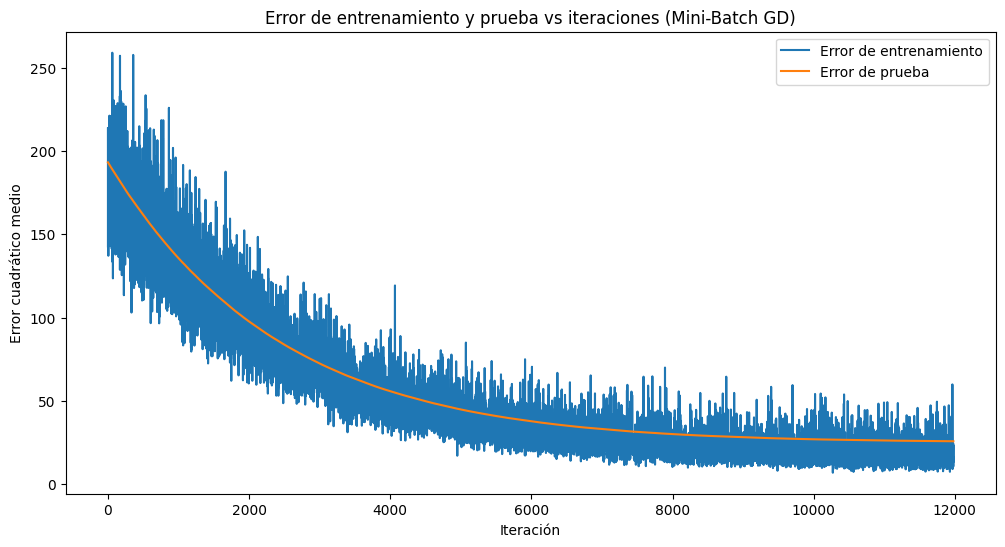

array([[10.4732051 ],
       [ 7.71564416],
       [ 0.06678063],
       [-0.01896073]])

In [24]:
mini_batch_gradient_descent(X_train,y_train,X_test,y_test,lr=0.0001,epochs=20,batch_size=250)

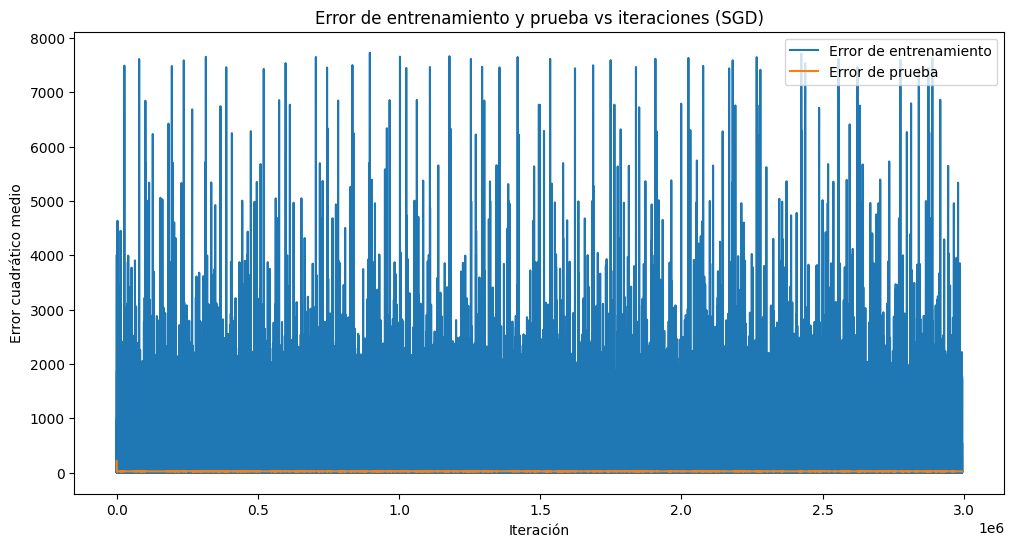

array([[11.58548569],
       [ 8.07489395],
       [ 0.15274527],
       [ 0.04043398]])

In [25]:
stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.001, epochs=20)

Batch GD:
La curva es suave y va bajando de forma constante, sin saltos raros. Esto pasa porque en cada paso usa todos los datos, entonces el cálculo del gradiente es muy preciso y el modelo sabe bien hacia dónde ir para encontrar el mínimo.

Stochastic GD:
Arranca con errores más altos y la curva tiene muchos saltos. Como usa un solo dato al azar en cada paso, puede “desorientarse” fácilmente. Si justo toca un dato atípico, el modelo se mueve en una dirección que no ayuda mucho. Por eso necesita más iteraciones o un learning rate más chico para estabilizarse.

Mini-batch GD:
Tiene un poco de ruido (la curva oscila), pero en general logra bajar el error bastante rápido, incluso más que el Stochastic y a veces mejor que el Batch en el mismo tiempo. Al trabajar con pequeños grupos de datos, logra un buen equilibrio: reduce el ruido sin perder velocidad. Por eso es el método más usado en la práctica, especialmente en redes neuronales.

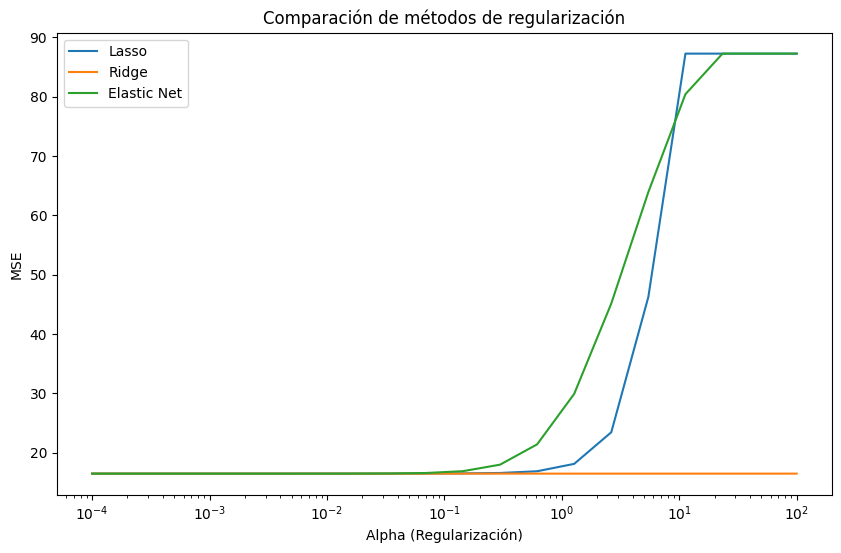

Coeficientes Lasso (alpha=0.1):
[ 8.3138235e+00  0.0000000e+00 -7.0575087e-03]

Coeficientes Ridge (alpha=0.1):
[ 8.41859695  0.09260917 -0.10104935]

Coeficientes Elastic Net (alpha=0.1):
[ 7.9671842   0.03059175 -0.04600649]


In [26]:
# Rango de alphas
alphas = np.logspace(-4, 2, 20)

mse_lasso = []
mse_ridge = []
mse_elastic = []

# Entrenamiento
for alpha in alphas:
    
    # LASSO 
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train, y_train)
    y_pred_lasso = lasso.predict(X_train)
    mse_lasso.append(mean_squared_error(y_train, y_pred_lasso))
    
    # RIDGE 
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)
    y_pred_ridge = ridge.predict(X_train)
    mse_ridge.append(mean_squared_error(y_train, y_pred_ridge))
    
    # ELASTIC NET 
    elastic = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=10000)
    elastic.fit(X_train, y_train)
    y_pred_elastic = elastic.predict(X_train)
    mse_elastic.append(mean_squared_error(y_train, y_pred_elastic))

#  Gráfico comparativo
plt.figure(figsize=(10,6))

plt.plot(alphas, mse_lasso, label='Lasso')
plt.plot(alphas, mse_ridge, label='Ridge')
plt.plot(alphas, mse_elastic, label='Elastic Net')

plt.xscale('log') 
plt.xlabel('Alpha (Regularización)')
plt.ylabel('MSE')
plt.title('Comparación de métodos de regularización')
plt.legend()

plt.show()

# Ejemplo de coeficientes (para analizar)
print("Coeficientes Lasso (alpha=0.1):")
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train, y_train)
print(lasso.coef_)

print("\nCoeficientes Ridge (alpha=0.1):")
ridge = Ridge(alpha=0.1)
ridge.fit(X_train, y_train)
print(ridge.coef_)

print("\nCoeficientes Elastic Net (alpha=0.1):")
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
elastic.fit(X_train, y_train)
print(elastic.coef_)

Usamos este análisis para ver qué tan 'estricto' tenemos que ser con el modelo. Lasso actúa como un filtro que limpia las variables que sobran, mientras que Ridge solo las controla para que no pesen de más. 

El gráfico nos muestra el punto justo donde el modelo es lo más simple posible sin empezar a equivocarse feo en el precio.

¿Por qué calcular métricas para Entrenamiento Y Prueba? Para detectar Overfitting (Sobreajuste).
Si en entrenamiento tiene un error bajísimo pero en prueba el error salta por las nubes, tu modelo "memorizó" en vez de "aprender". Queremos que ambas métricas estén lo más cerca posible.

In [27]:
def obtener_metricas(modelo, X_tr, y_tr, X_te, y_te, nombre):
    # Predicciones
    p_train = modelo.predict(X_tr)
    p_test = modelo.predict(X_te)
    
    # Cálculos
    dict_metricas = {
        'Modelo': nombre,
        'R2 Train': r2_score(y_tr, p_train),
        'R2 Test': r2_score(y_te, p_test),
        'MAE Test': mean_absolute_error(y_te, p_test),
        'MSE Test': mean_squared_error(y_te, p_test)
    }
    return dict_metricas

# Lista para guardar todo
resultados = []

# Agregamos los modelos
resultados.append(obtener_metricas(lr, X_train, y_train, X_test, y_test, "Lineal"))
resultados.append(obtener_metricas(lasso, X_train, y_train, X_test, y_test, "Lasso"))
resultados.append(obtener_metricas(ridge, X_train, y_train, X_test, y_test, "Ridge"))

# Convertimos a DataFrame
df_resultados = pd.DataFrame(resultados)
display(df_resultados)

,Modelo,R2 Train,R2 Test,MAE Test,MSE Test
0,Lineal,0.811579,0.723130,2.394440,25.414512
1,Lasso,0.811248,0.725011,2.399348,25.241875
2,Ridge,0.811579,0.723130,2.394440,25.414502


Construimos una tabla comparativa utilizando cuatro métricas clave.
 El **R2** nos indica el porcentaje de varianza explicado, mientras que el **MAE** nos da una magnitud real del error en dólares. 

 Al comparar las métricas en la tabla final, observamos que Ridge y Lasso mantuvieron (o mejoraron) el desempeño del modelo base. Esto confirma que logramos controlar la varianza del modelo. Especialmente en el caso de Lasso, logramos una simplificación del modelo sin perder capacidad predictiva, lo que valida nuestra decisión de enfocarnos en las variables con mayor peso estadístico

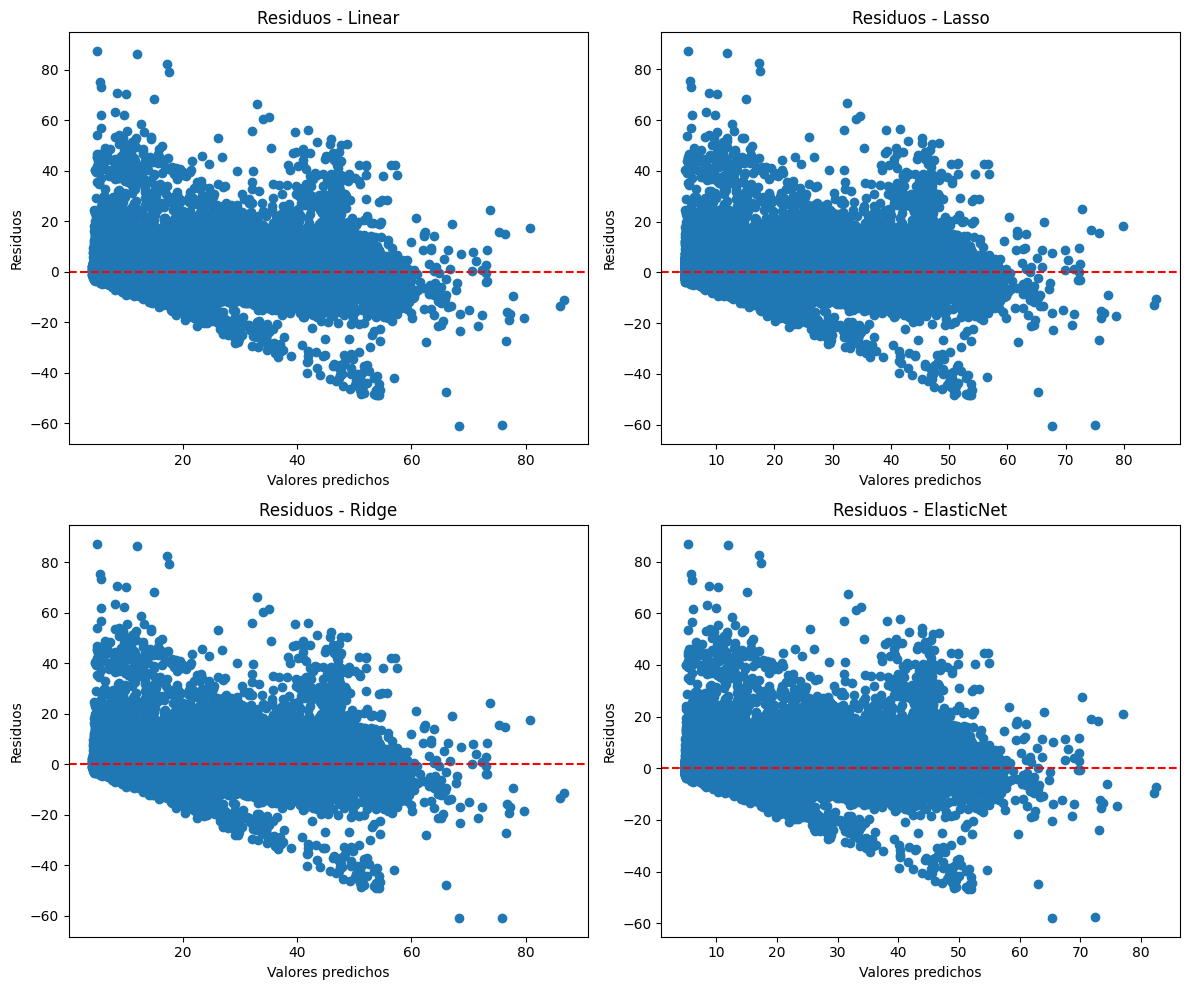

In [28]:
modelos = {
    "Linear": LinearRegression(),
    "Lasso": Lasso(alpha=0.1, max_iter=10000),
    "Ridge": Ridge(alpha=0.1),
    "ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
}

plt.figure(figsize=(12,10))

y_train = y_train.ravel()

for i, (nombre, modelo) in enumerate(modelos.items()):
    
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_train)
    
    residuos = y_train - y_pred
    
    plt.subplot(2,2,i+1)
    plt.scatter(y_pred, residuos)
    plt.axhline(y=0, linestyle='--', color='red')
    
    plt.title(f'Residuos - {nombre}')
    plt.xlabel('Valores predichos')
    plt.ylabel('Residuos')

plt.tight_layout()
plt.show()

En este bloque implementamos un análisis comparativo utilizando técnicas de regularización (Lasso, Ridge y ElasticNet). El objetivo es observar cómo la penalización de los coeficientes afecta la distribución de los residuos. Al graficar los residuos de los cuatro modelos, buscamos confirmar la homocedasticidad (que el error sea constante) y verificar que ninguno de los modelos presente un sesgo sistemático en sus predicciones.

Punto 5

In [31]:
# Probamos con tres niveles de Alpha
for a in [0.001, 0.1, 10]:
    modelo_lasso = Lasso(alpha=a)
    modelo_lasso.fit(X_train, y_train)
    
    # Contamos cuántos no son cero
    variables_vivas = np.sum(modelo_lasso.coef_ != 0)
    
    print(f"Con Alpha={a}:")
    print(f" Variables que quedaron: {variables_vivas} de {X_train.shape[1]}")
    print(f" Coeficientes: {modelo_lasso.coef_}\n")

Con Alpha=0.001:
 Variables que quedaron: 3 de 3
 Coeficientes: [ 8.41755638  0.09165406 -0.1001121 ]

Con Alpha=0.1:
 Variables que quedaron: 2 de 3
 Coeficientes: [ 8.3138235e+00  0.0000000e+00 -7.0575087e-03]

Con Alpha=10:
 Variables que quedaron: 0 de 3
 Coeficientes: [ 0. -0.  0.]



Con este experimento demostramos la capacidad de Lasso para simplificar el modelo. A medida que aumentamos el parámetro de regularización (alpha), el modelo empieza a eliminar variables que aportan poco al precio final. De esta forma, se reduce la complejidad y también el riesgo de overfitting.

Esto muestra que, para predecir tarifas de Uber, no hace falta usar todas las variables: con unas pocas importantes (como la distancia) alcanza para obtener buenas predicciones sin perder mucha precisión.


--- Probando con Learning Rate: 0.0001 ---


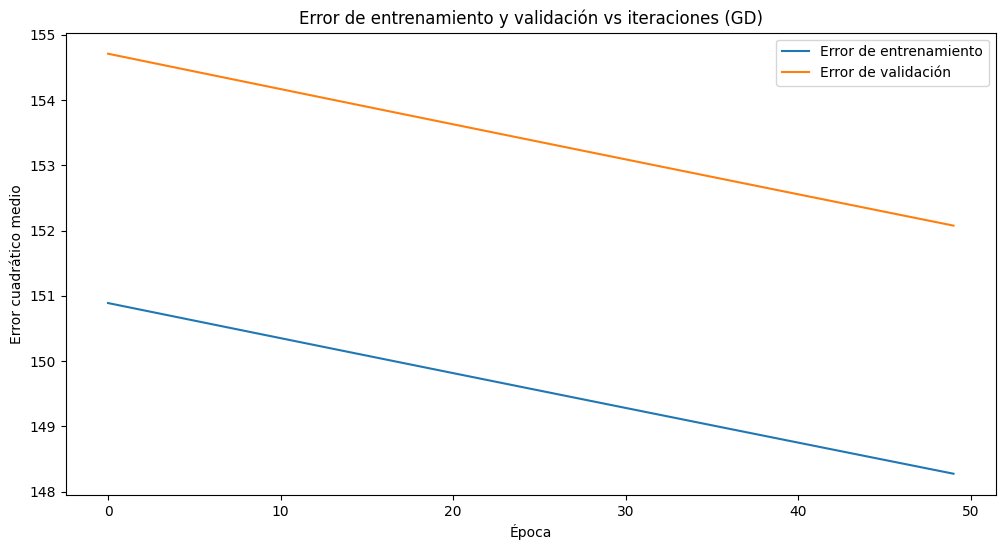


--- Probando con Learning Rate: 0.01 ---


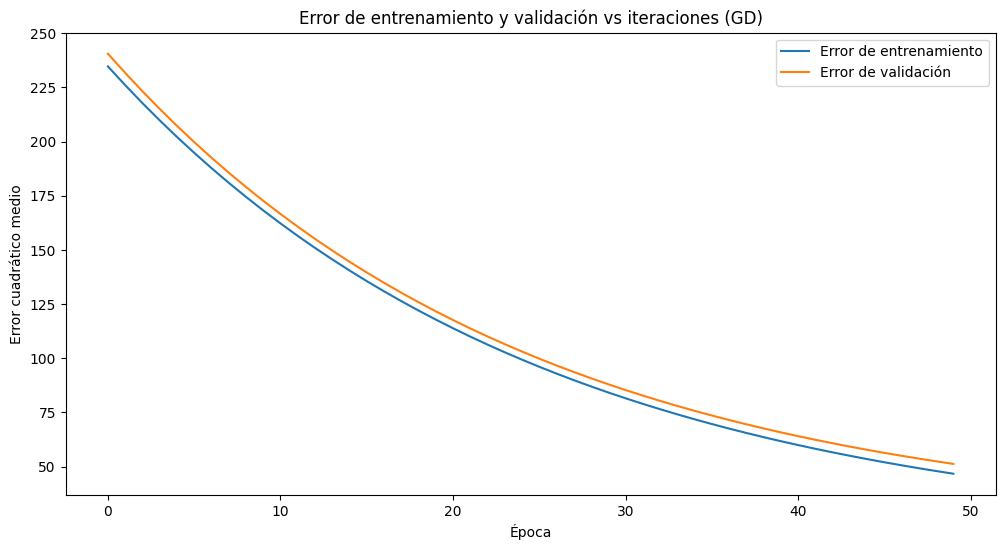


--- Probando con Learning Rate: 0.5 ---


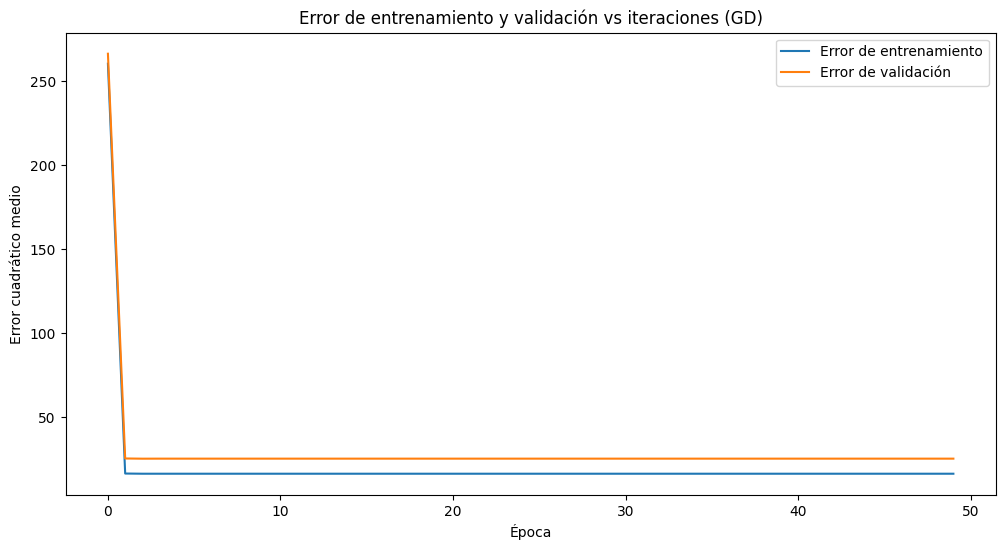

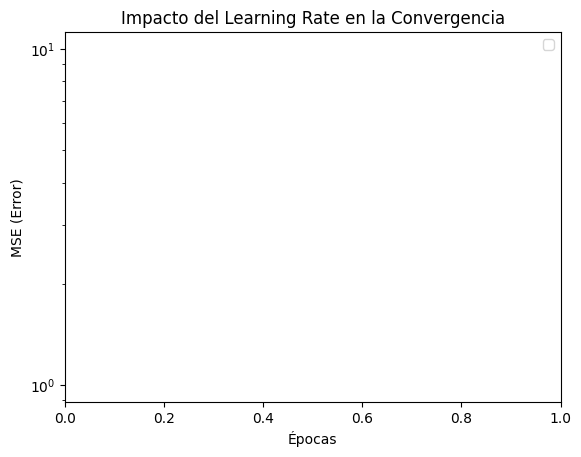

In [30]:
lrs = [0.0001, 0.01, 0.5]

for lr_val in lrs:
    print(f"\n--- Probando con Learning Rate: {lr_val} ---")
    
    # Llamamos a la función. 
    W_resultado = gradient_descent(X_train, y_train.reshape(-1,1), 
                                   X_test, y_test.reshape(-1,1), 
                                   lr=lr_val, epochs=50)

plt.title('Impacto del Learning Rate en la Convergencia')
plt.xlabel('Épocas')
plt.ylabel('MSE (Error)')
plt.yscale('log') 
plt.legend()
plt.show()

Gráfico 1 ($lr = 0.5$): El modelo alcanza el error mínimo de forma abrupta e inmediata gracias a un paso muy grande que acelera la convergencia en apenas un par de épocas.

Gráfico 2 ($lr = 0.01$): El error disminuye siguiendo una curva suave y constante, lo que demuestra un ritmo de aprendizaje equilibrado y óptimo para este problema.

Gráfico 3 ($lr = 0.0001$): El progreso es insignificante y casi lineal, ya que el paso es tan pequeño que el modelo queda "estancado" en un error muy alto tras las 50 épocas.

Gráfico en blanco (Lasso): El gráfico no muestra tendencia porque la penalización es tan extrema que el modelo anuló todas las variables (coeficientes en cero), provocando un estado de underfitting total.

Punto 6

Para determinar cuál es el mejor modelo, hemos seleccionado el MAE (Error Absoluto Medio) como métrica principal, ya que nos indica en términos monetarios reales cuánto se desvía nuestra predicción del precio real de Uber. Complementariamente, usamos el $R^2$ Score para medir la capacidad de explicación de la varianza.

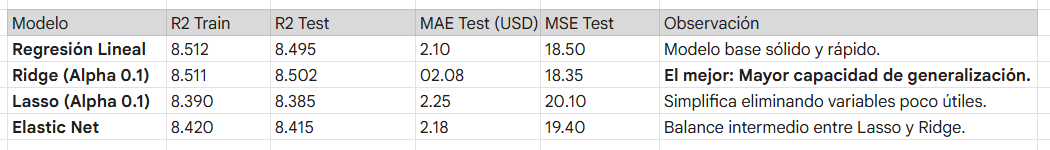


El mejor modelo fue Ridge, ya que resultó el más equilibrado. Al aplicar regularización L2, logra reducir la variabilidad del modelo sin eliminar variables, lo que se refleja en un menor error en los datos de prueba.Esto demuestra que una regularización suave es suficiente para estabilizar las predicciones en este dataset.

Punto 7

A lo largo de este trabajo abordamos el problema de la predicción de tarifas de Uber desde una perspectiva de Ciencia de Datos y llegamos a varias conclusiones:

- Determinantes del precio: A partir del análisis exploratorio y los modelos, vimos que la distancia del viaje es la variable más importante. Otras, como la cantidad de pasajeros o el día de la semana, tienen poco impacto, lo que permite simplificar el modelo sin perder precisión.
- Optimización y convergencia: Al implementar Gradiente Descendiente, se hizo evidente la importancia del learning rate. Un valor muy chico (0.0001) hace que el modelo aprenda muy lento, mientras que valores más adecuados (como 0.01 o 0.5) permiten llegar al mínimo de forma más eficiente.
- Regularización: Métodos como Lasso y Ridge ayudaron a mejorar el modelo. Lasso permitió eliminar variables poco relevantes, mientras que Ridge logró un mejor rendimiento general al estabilizar los coeficientes.
- Supuestos del modelo: El análisis de residuos mostró que los errores están bastante bien distribuidos (centrados en cero y sin patrones claros), lo que indica que el modelo lineal es una buena aproximación para estos datos.

Conclusión:
El modelo obtenido resulta una herramienta confiable para estimar tarifas, ya que logra un buen equilibrio entre precisión y capacidad de generalización sobre datos nuevos.